# Power Output Analysis — 500 kW PV Plant (Pune, 2023)

This notebook analyses the SCADA power output data from the 500 kW rooftop PV plant located in Pune, Maharashtra (India).  
The dataset covers the full year 2023 at hourly resolution.  
It includes power generation readings, irradiance estimates, meteorological co-variates, and anomaly labels.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from pathlib import Path

DATA = Path('../solar_forecast/data')
FIG  = Path('figures')
FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MONTHS     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
SEASON_CLR = {
    'Winter':       '#4472C4',
    'Pre-Monsoon':  '#ED7D31',
    'Monsoon':      '#70AD47',
    'Post-Monsoon': '#9E480E',
}
ANOMALY_MARKERS = {
    'inverter_trip':   ('X',  '#D62728'),
    'string_fault':    ('s',  '#FF7F0E'),
    'mppt_underperf':  ('^',  '#9467BD'),
    'normal':          ('.',  '#AAAAAA'),
}

def month_to_season(m):
    if m in [12, 1, 2]:        return 'Winter'
    elif m in [3, 4, 5]:       return 'Pre-Monsoon'
    elif m in [6, 7, 8, 9]:    return 'Monsoon'
    else:                      return 'Post-Monsoon'

print('Setup complete.')

Setup complete.


## 1. Load SCADA Data

In [2]:
df = pd.read_csv(DATA / 'pune_500kw_hourly.csv', parse_dates=['timestamp'])
df['month']    = df['timestamp'].dt.month
df['hour']     = df['timestamp'].dt.hour
df['season']   = df['month'].map(month_to_season)
df['date']     = df['timestamp'].dt.date

print(f'Shape       : {df.shape}')
print(f'Columns     : {list(df.columns)}')
print(f'Date range  : {df["timestamp"].min()}  →  {df["timestamp"].max()}')
df.head()

Shape       : (8760, 18)
Columns     : ['timestamp', 'power_kw', 'ghi', 'dni', 'dhi', 'poa_global', 'temp_air', 'humidity', 'wind_speed', 'cloud_cover', 'zenith_deg', 'azimuth_solar_deg', 'is_anomaly', 'anomaly_type', 'month', 'hour', 'season', 'date']
Date range  : 2023-01-01 00:00:00+05:30  →  2023-12-31 23:00:00+05:30


,timestamp,power_kw,ghi,dni,dhi,poa_global,temp_air,humidity,wind_speed,cloud_cover,zenith_deg,azimuth_solar_deg,is_anomaly,anomaly_type,month,hour,season,date
0,2023-01-01 00:00:00+05:30,0.0,0.0,0.0,0.0,0.0,16.9,81,1.66,0.81,170.093800,241.640414,False,normal,1,0,Winter,2023-01-01
1,2023-01-01 01:00:00+05:30,0.0,0.0,0.0,0.0,0.0,17.7,76,1.03,0.69,173.182533,131.737340,False,normal,1,1,Winter,2023-01-01
2,2023-01-01 02:00:00+05:30,0.0,0.0,0.0,0.0,0.0,15.1,88,1.36,0.53,160.331615,106.612576,False,normal,1,2,Winter,2023-01-01
3,2023-01-01 03:00:00+05:30,0.0,0.0,0.0,0.0,0.0,15.0,86,1.00,0.56,146.590757,103.886631,False,normal,1,3,Winter,2023-01-01
4,2023-01-01 04:00:00+05:30,0.0,0.0,0.0,0.0,0.0,13.4,92,1.21,0.50,132.805544,104.552253,False,normal,1,4,Winter,2023-01-01


In [3]:
df[['power_kw', 'ghi', 'temp_air', 'humidity', 'wind_speed',
    'cloud_cover', 'zenith_deg']].describe().round(3)

,power_kw,ghi,temp_air,humidity,wind_speed,cloud_cover,zenith_deg
count,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000
mean,99.152,229.631,24.468,65.583,2.600,0.469,89.819
std,130.483,304.231,4.923,24.379,1.583,0.421,45.141
min,0.000,0.000,9.600,9.000,0.000,0.000,4.425
25%,0.000,0.000,21.600,46.000,1.400,0.020,50.424
50%,3.645,9.000,23.900,71.000,2.250,0.350,90.482
75%,201.836,472.000,27.600,88.000,3.610,0.990,129.255
max,420.242,1024.000,40.800,100.000,8.540,1.000,177.044


## 2. Anomaly Type Counts and Rates

In [4]:
total = len(df)
anom  = df[df['is_anomaly'] == True]
print(f'Total records   : {total}')
print(f'Anomalous hours : {len(anom)}  ({100*len(anom)/total:.2f}%)')
print()

type_counts = df[df['anomaly_type'] != 'normal']['anomaly_type'].value_counts()
type_rates  = (type_counts / total * 100).round(3)
anom_summary = pd.DataFrame({
    'count': type_counts,
    'rate_%': type_rates
})
print('Anomaly type breakdown:')
display(anom_summary)

Total records   : 8760
Anomalous hours : 315  (3.60%)

Anomaly type breakdown:


,count,rate_%
anomaly_type,,
mppt_underperf,164,1.872
string_fault,123,1.404
inverter_trip,28,0.320


## 3. Power Distribution Histograms

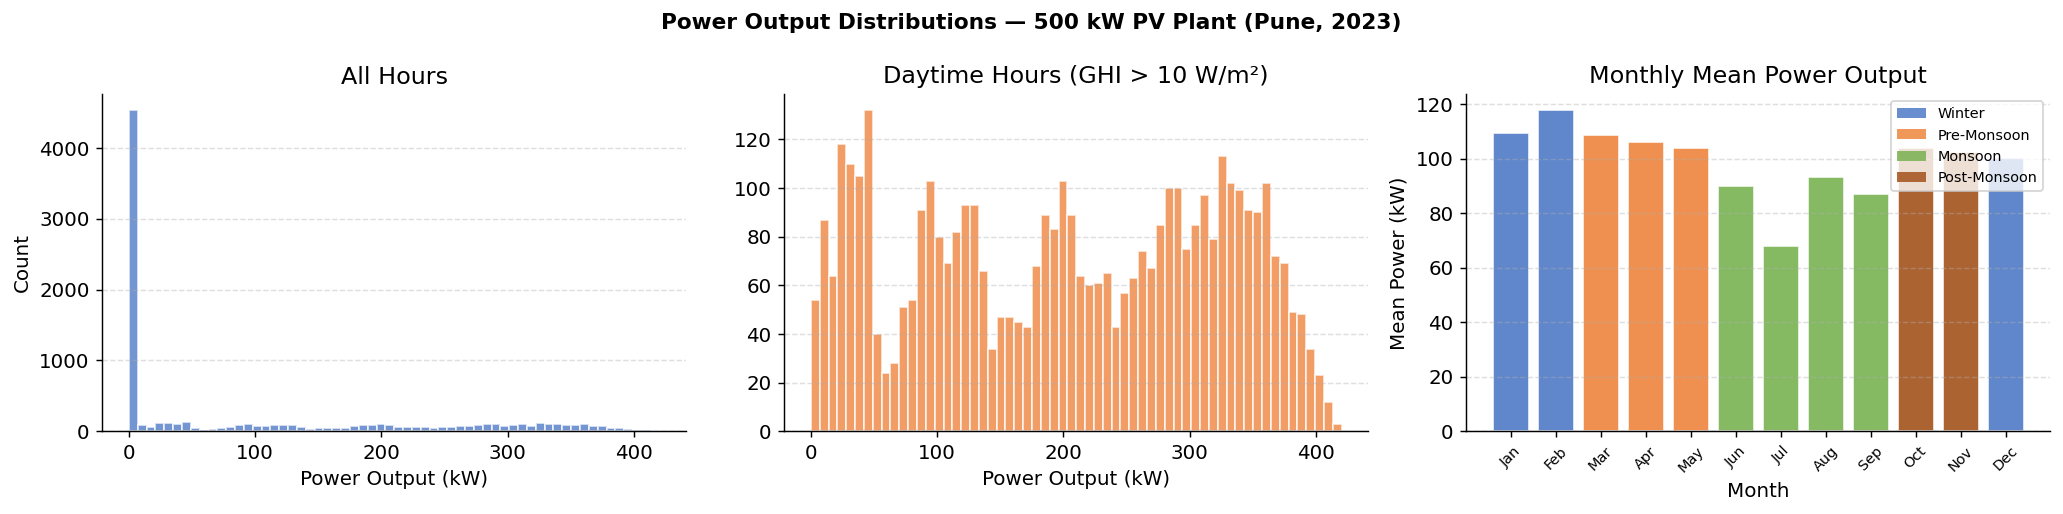

Saved: power_distributions.png


In [5]:
daytime = df[(df['hour'].between(6, 18)) & (df['ghi'] > 10)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Power Output Distributions — 500 kW PV Plant (Pune, 2023)',
             fontsize=12, fontweight='bold')

# All hours
axes[0].hist(df['power_kw'], bins=60, color='#4472C4', alpha=0.75, edgecolor='white')
axes[0].set_title('All Hours')
axes[0].set_xlabel('Power Output (kW)')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Daytime only
axes[1].hist(daytime['power_kw'], bins=60, color='#ED7D31', alpha=0.75, edgecolor='white')
axes[1].set_title('Daytime Hours (GHI > 10 W/m²)')
axes[1].set_xlabel('Power Output (kW)')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Monthly mean
monthly_mean = df.groupby('month')['power_kw'].mean()
bar_colors = [SEASON_CLR[month_to_season(m)] for m in range(1, 13)]
axes[2].bar(range(1, 13), monthly_mean.values, color=bar_colors, alpha=0.85, edgecolor='white')
axes[2].set_title('Monthly Mean Power Output')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean Power (kW)')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(MONTHS, rotation=45, fontsize=8)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

# Season legend for bar chart
handles = [mpatches.Patch(facecolor=c, alpha=0.8, label=s) for s, c in SEASON_CLR.items()]
axes[2].legend(handles=handles, fontsize=8, loc='upper right')

plt.tight_layout()
fig.savefig(FIG / 'power_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: power_distributions.png')

## 4. Diurnal Power Profile by Season

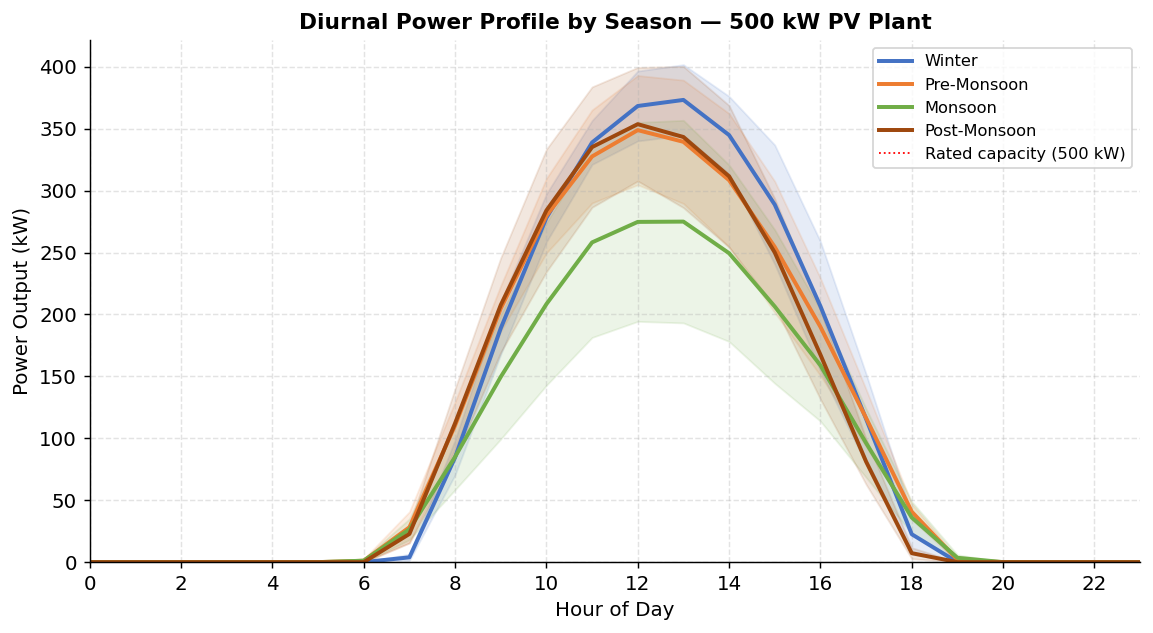

Saved: power_diurnal_by_season.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for season, clr in SEASON_CLR.items():
    sub = df[df['season'] == season].groupby('hour')['power_kw']
    mn  = sub.mean()
    sd  = sub.std()
    ax.plot(mn.index, mn.values, color=clr, linewidth=2.2, label=season)
    ax.fill_between(mn.index, mn - sd, mn + sd, color=clr, alpha=0.13)

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Power Output (kW)', fontsize=11)
ax.set_title('Diurnal Power Profile by Season — 500 kW PV Plant', fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.set_ylim(bottom=0)
ax.axhline(500, linestyle=':', color='red', linewidth=1, label='Rated capacity (500 kW)')
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.35)

plt.tight_layout()
fig.savefig(FIG / 'power_diurnal_by_season.png', bbox_inches='tight')
plt.show()
print('Saved: power_diurnal_by_season.png')

## 5. One-Week Anomaly Visualisation (Dec 4–10, 2023)

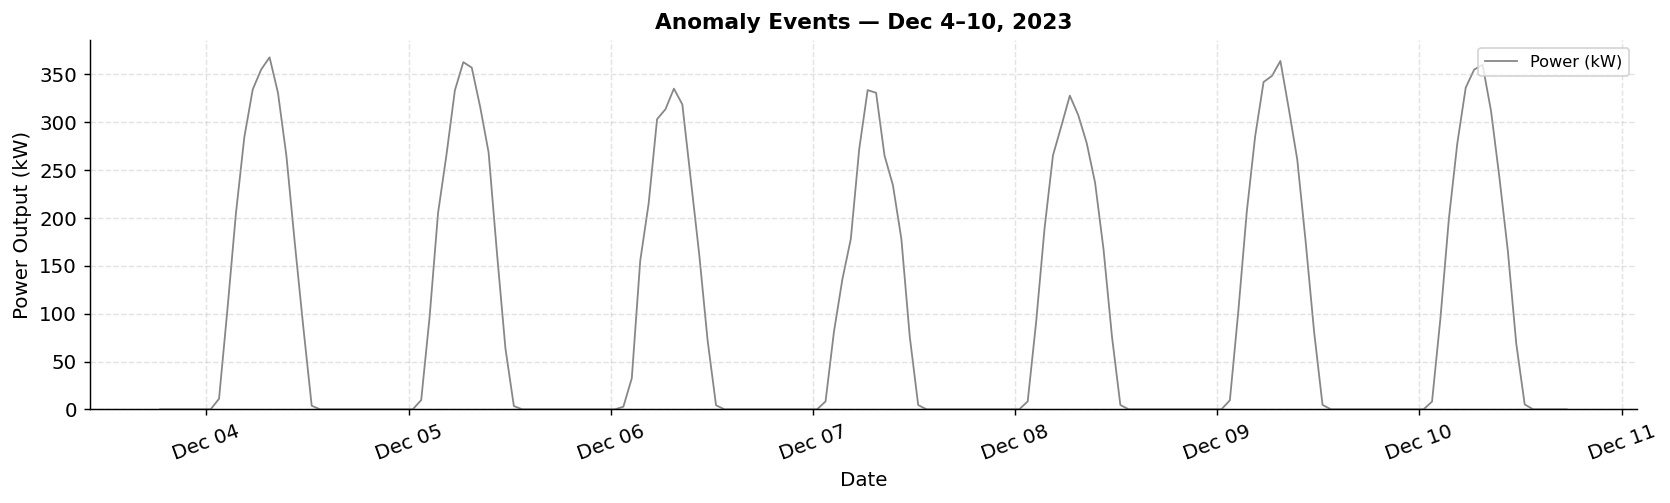

Saved: power_anomaly_week.png


In [7]:
week = df[
    (df['timestamp'] >= '2023-12-04') &
    (df['timestamp'] <  '2023-12-11')
].copy()

fig, ax = plt.subplots(figsize=(13, 4))

# Continuous power trace
ax.plot(week['timestamp'], week['power_kw'],
        color='#555555', linewidth=1.0, alpha=0.7, zorder=1, label='Power (kW)')

# Anomalous points
for atype, (mrk, clr) in ANOMALY_MARKERS.items():
    if atype == 'normal':
        continue
    sub = week[week['anomaly_type'] == atype]
    if len(sub):
        ax.scatter(sub['timestamp'], sub['power_kw'],
                   marker=mrk, color=clr, s=70, zorder=3, label=atype.replace('_', ' ').title())

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Power Output (kW)', fontsize=11)
ax.set_title('Anomaly Events — Dec 4–10, 2023', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)
ax.grid(linestyle='--', alpha=0.35)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20)

plt.tight_layout()
fig.savefig(FIG / 'power_anomaly_week.png', bbox_inches='tight')
plt.show()
print('Saved: power_anomaly_week.png')

## 6. Cloud Cover vs Power & Zenith Angle vs Power

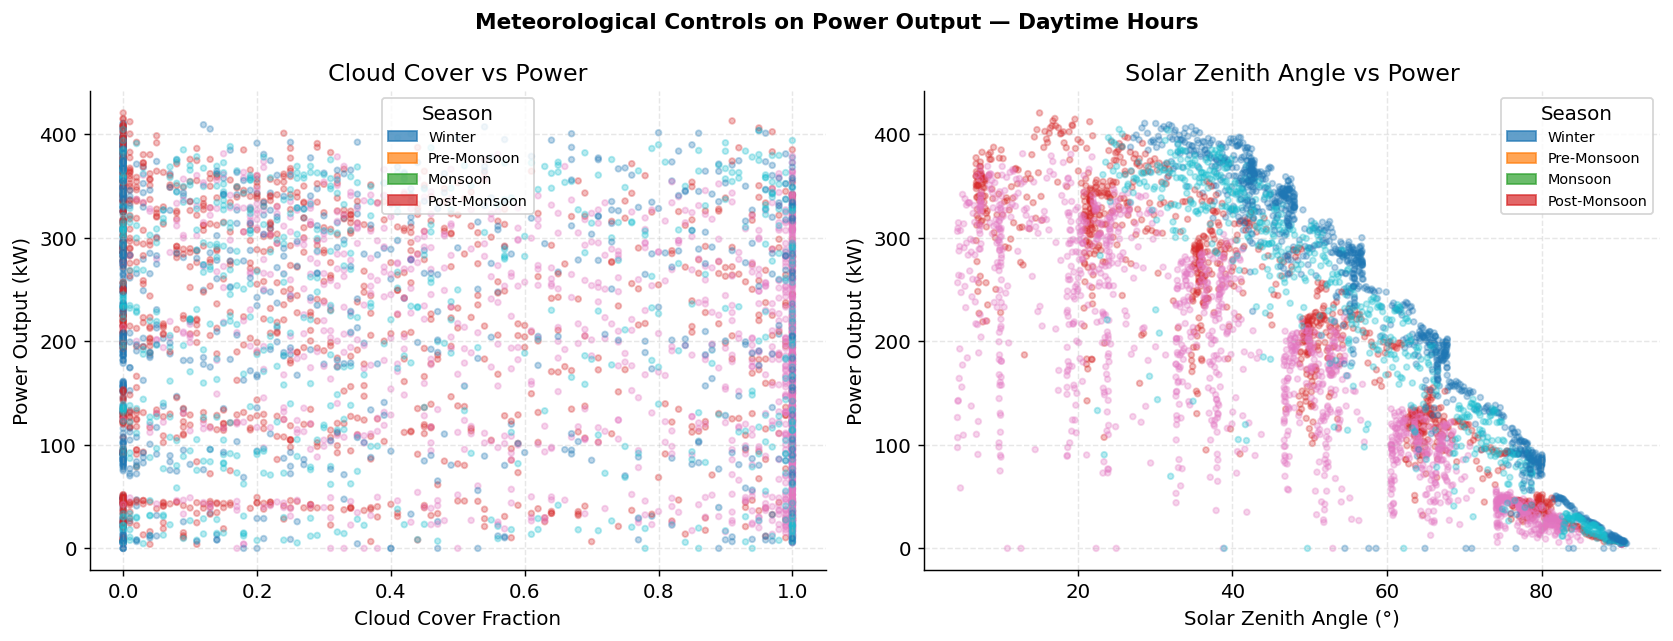

Saved: power_met_scatter.png


In [8]:
day = df[(df['ghi'] > 10) & (df['hour'].between(6, 18))].copy()
season_order = list(SEASON_CLR.keys())
day['season_idx'] = day['season'].map({s: i for i, s in enumerate(season_order)})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Meteorological Controls on Power Output — Daytime Hours',
             fontsize=12, fontweight='bold')

# Cloud cover vs power
axes[0].scatter(day['cloud_cover'], day['power_kw'],
                c=day['season_idx'], cmap='tab10',
                alpha=0.30, s=10, rasterized=True)
axes[0].set_xlabel('Cloud Cover Fraction')
axes[0].set_ylabel('Power Output (kW)')
axes[0].set_title('Cloud Cover vs Power')
axes[0].grid(linestyle='--', alpha=0.3)

# Season legend
handles = [mpatches.Patch(color=plt.cm.tab10(i / 9), alpha=0.7, label=s)
           for i, s in enumerate(season_order)]
axes[0].legend(handles=handles, fontsize=8, title='Season')

# Solar zenith vs power
axes[1].scatter(day['zenith_deg'], day['power_kw'],
                c=day['season_idx'], cmap='tab10',
                alpha=0.30, s=10, rasterized=True)
axes[1].set_xlabel('Solar Zenith Angle (°)')
axes[1].set_ylabel('Power Output (kW)')
axes[1].set_title('Solar Zenith Angle vs Power')
axes[1].grid(linestyle='--', alpha=0.3)
axes[1].legend(handles=handles, fontsize=8, title='Season')

plt.tight_layout()
fig.savefig(FIG / 'power_met_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: power_met_scatter.png')

## 7. Chronological Train / Val / Test Split

The dataset is split chronologically as follows:

| Split | Period       | Fraction |
|-------|--------------|----------|
| Train | Jan – Aug    | 70 %     |
| Val   | Sep – Oct    | 15 %     |
| Test  | Nov – Dec    | 15 %     |

Normalisation statistics (z-score) are fitted on the training split only and applied to all splits.

Train :  5832 rows  (66.6%)  Jan–Aug
Val   :  1464 rows  (16.7%)  Sep–Oct
Test  :  1464 rows  (16.7%)  Nov–Dec


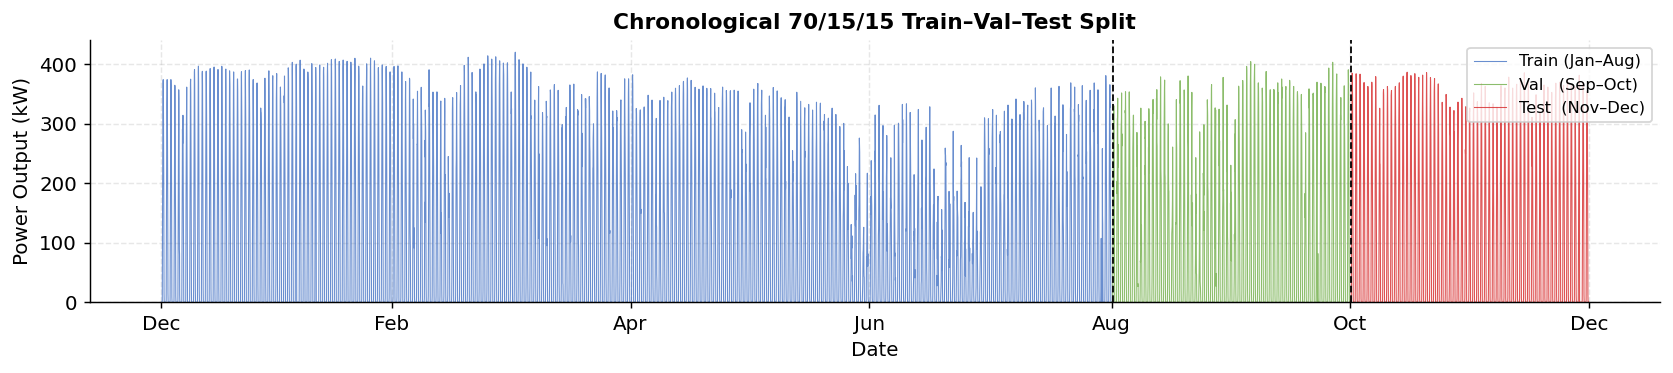

Saved: power_train_val_test_split.png


In [9]:
train_df = df[df['month'] <= 8]
val_df   = df[df['month'].between(9, 10)]
test_df  = df[df['month'] >= 11]

print(f'Train : {len(train_df):5d} rows  ({100*len(train_df)/len(df):.1f}%)  Jan–Aug')
print(f'Val   : {len(val_df):5d} rows  ({100*len(val_df)/len(df):.1f}%)  Sep–Oct')
print(f'Test  : {len(test_df):5d} rows  ({100*len(test_df)/len(df):.1f}%)  Nov–Dec')

fig, ax = plt.subplots(figsize=(13, 3))

for split_df, label, clr in [
    (train_df, 'Train (Jan–Aug)',  '#4472C4'),
    (val_df,   'Val   (Sep–Oct)',  '#70AD47'),
    (test_df,  'Test  (Nov–Dec)',  '#D62728'),
]:
    ax.plot(split_df['timestamp'], split_df['power_kw'],
            color=clr, linewidth=0.6, alpha=0.8, label=label)

# Split boundaries
for bd in ['2023-09-01', '2023-11-01']:
    ax.axvline(pd.Timestamp(bd), color='black', linestyle='--', linewidth=1)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Power Output (kW)', fontsize=11)
ax.set_title('Chronological 70/15/15 Train–Val–Test Split', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)
ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG / 'power_train_val_test_split.png', bbox_inches='tight')
plt.show()
print('Saved: power_train_val_test_split.png')